In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the IBM HR Employee Attrition dataset
url = "https://raw.githubusercontent.com/dasarpai/DAI-Datasets/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)   # Should show (1470, 35)
df.head()

✅ Dataset loaded successfully!
Shape of dataset: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
print(df['Attrition'].value_counts())
print("\nAttrition Rate:", round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12 %


In [6]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [8]:
# Make a copy so original data is safe
df_clean = df.copy()

# 1. Drop unnecessary columns (these have only 1 value or are not useful)
columns_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df_clean.drop(columns=columns_to_drop)

# 2. Convert Attrition to 0 and 1 (for machine learning later)
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Check the result
print("Shape after cleaning:", df_clean.shape)
print("\nAttrition values now:")
print(df_clean['Attrition'].value_counts())
print("\nFirst 5 rows after cleaning:")
df_clean.head()

Shape after cleaning: (1470, 31)

Attrition values now:
Attrition
0    1233
1     237
Name: count, dtype: int64

First 5 rows after cleaning:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


/tmp/ipykernel_860/3930041797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df_clean, palette='Set2')


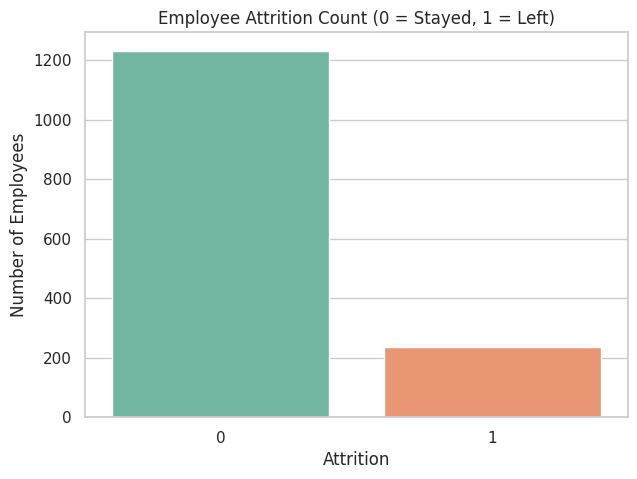

In [9]:
# Attrition count plot
plt.figure(figsize=(7,5))
sns.countplot(x='Attrition', data=df_clean, palette='Set2')
plt.title('Employee Attrition Count (0 = Stayed, 1 = Left)')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

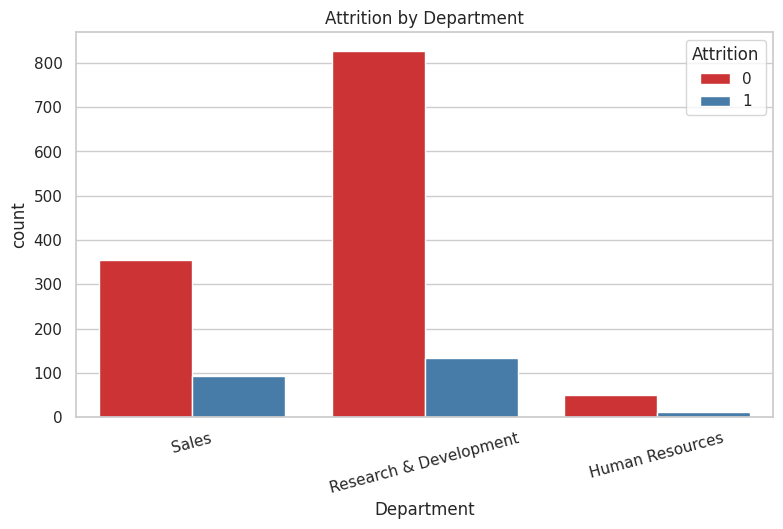

In [10]:
plt.figure(figsize=(9,5))
sns.countplot(x='Department', hue='Attrition', data=df_clean, palette='Set1')
plt.title('Attrition by Department')
plt.xticks(rotation=15)
plt.show()

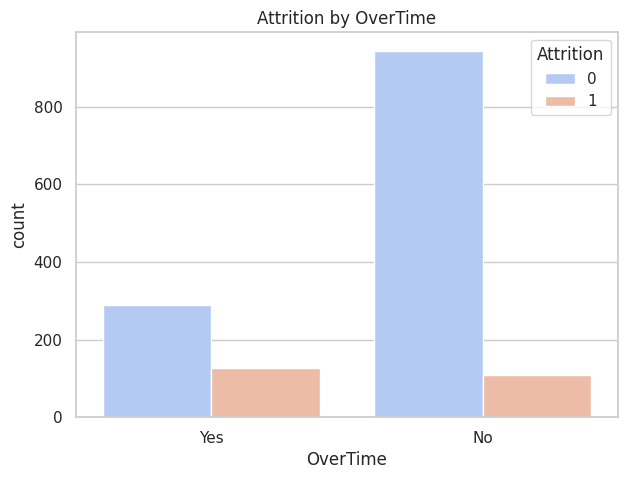

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(x='OverTime', hue='Attrition', data=df_clean, palette='coolwarm')
plt.title('Attrition by OverTime')
plt.show()

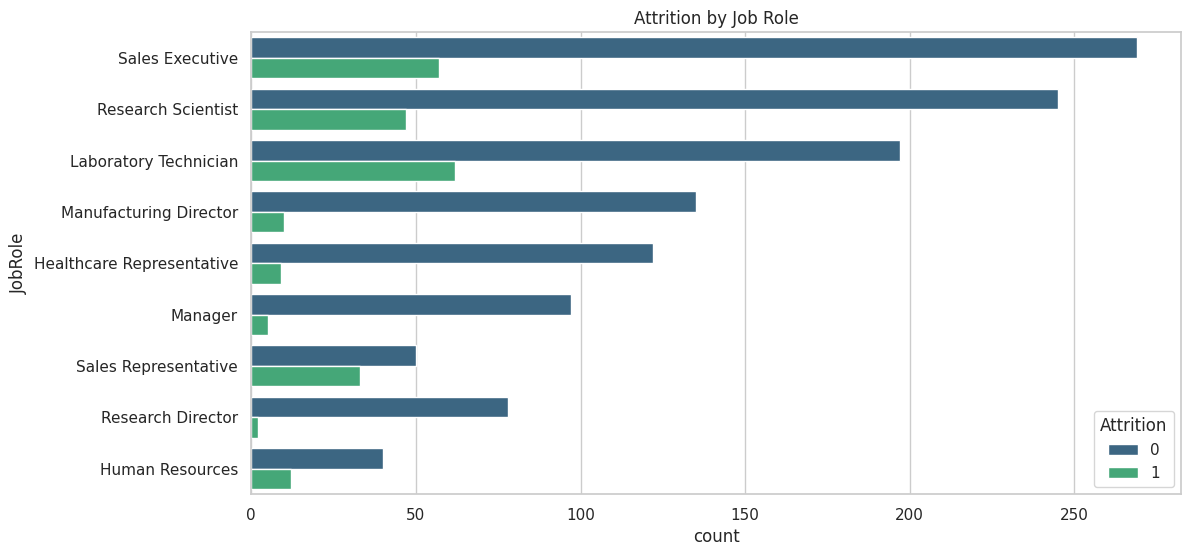

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(y='JobRole', hue='Attrition', data=df_clean, palette='viridis')
plt.title('Attrition by Job Role')
plt.show()

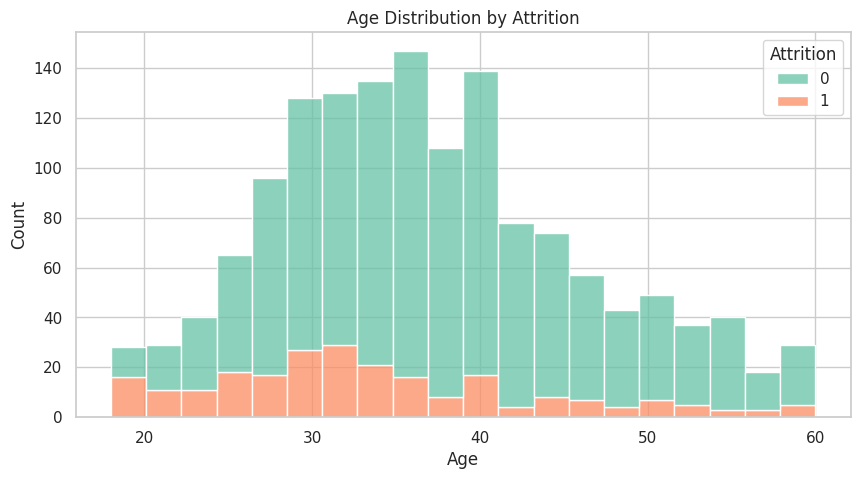

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_clean, x='Age', hue='Attrition', multiple='stack', palette='Set2', bins=20)
plt.title('Age Distribution by Attrition')
plt.show()

/tmp/ipykernel_860/1336337310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, palette='Set3')


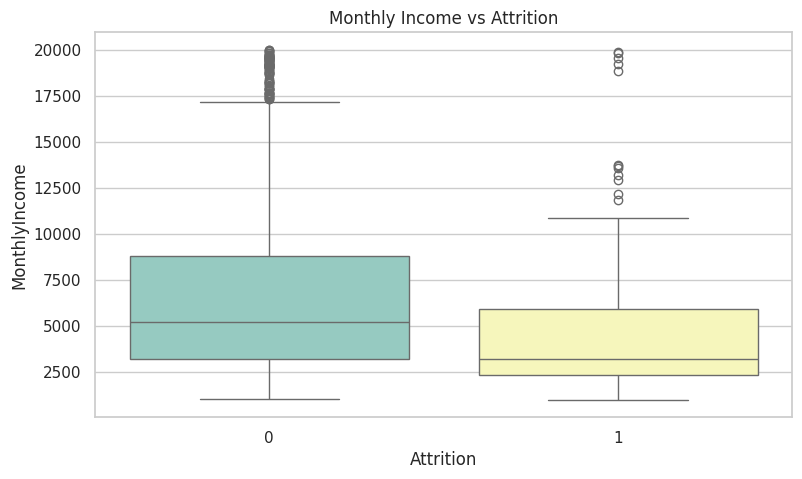

In [14]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, palette='Set3')
plt.title('Monthly Income vs Attrition')
plt.show()

/tmp/ipykernel_860/219333924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='YearsAtCompany', data=df_clean, palette='coolwarm')


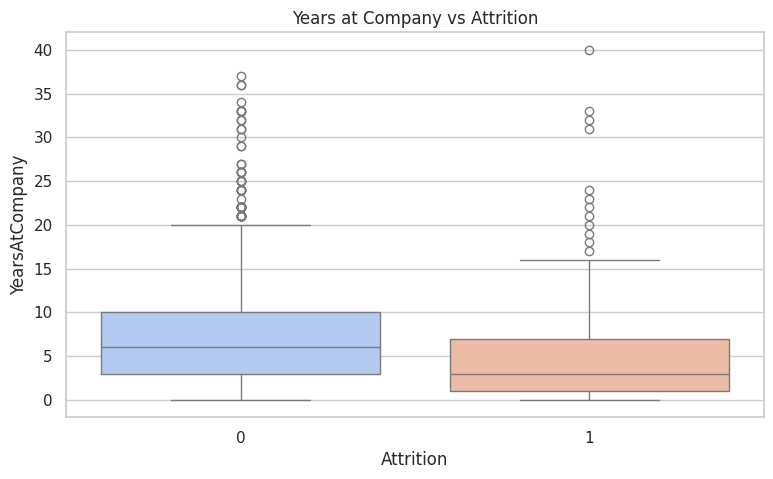

In [15]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df_clean, palette='coolwarm')
plt.title('Years at Company vs Attrition')
plt.show()

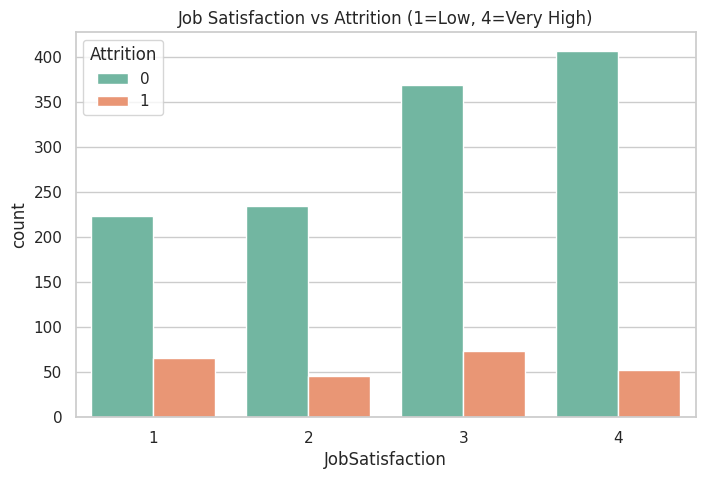

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df_clean, palette='Set2')
plt.title('Job Satisfaction vs Attrition (1=Low, 4=Very High)')
plt.show()

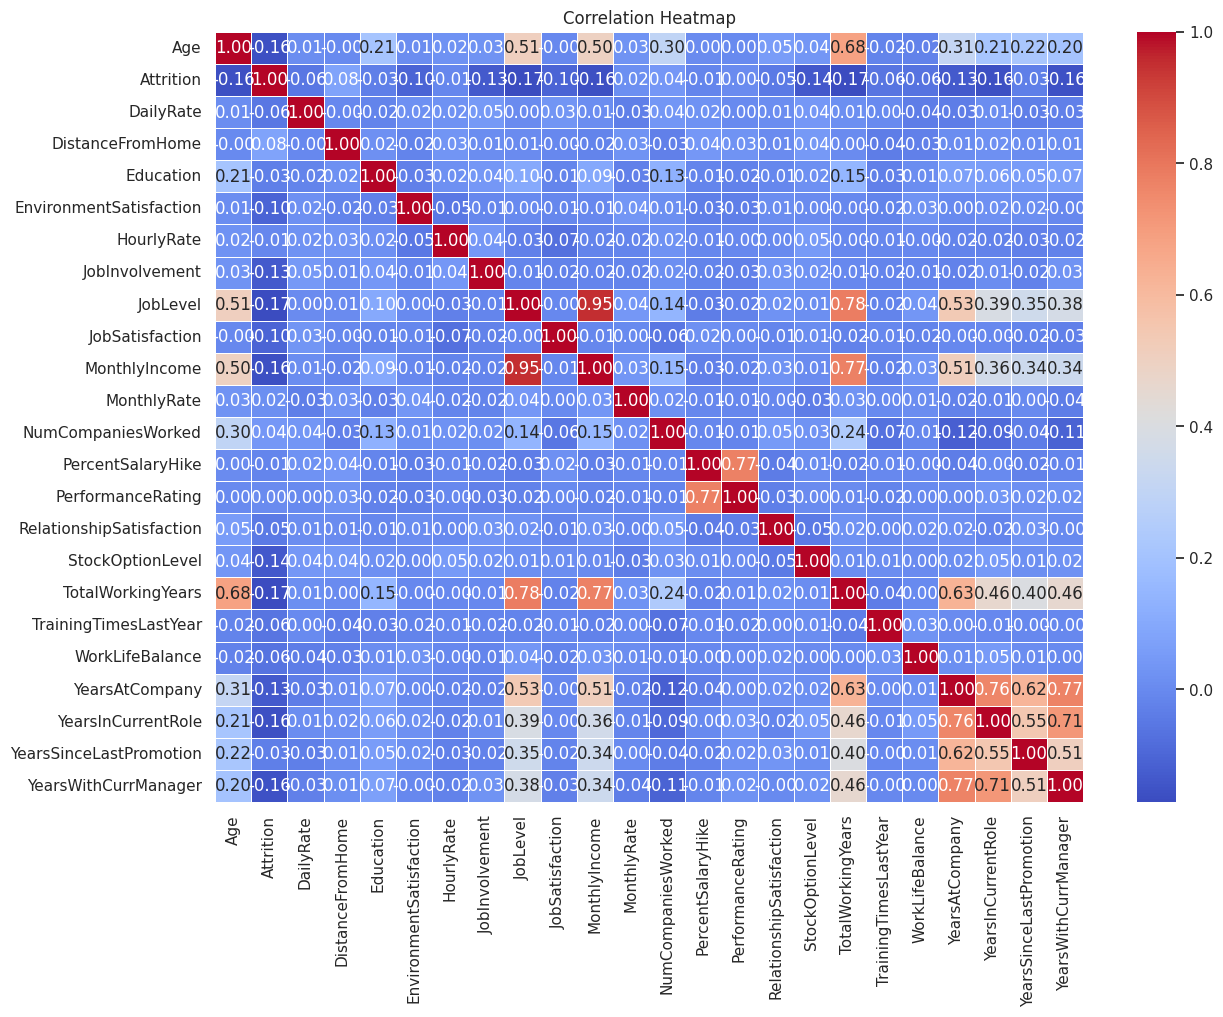

In [17]:
# Select only numerical columns
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Key Business Insights

1. Overall attrition rate is around **16%**.
2. Employees who work **OverTime** have a much higher chance of leaving.
3. **Sales Department** has higher attrition compared to Research & Development.
4. **Laboratory Technicians** and **Sales Representatives** show high attrition.
5. Younger employees (especially below 35 years) leave more frequently.
6. Employees with **lower Monthly Income** tend to leave more.
7. Employees with **low Job Satisfaction** (rating 1 or 2) leave more often.
8. People who have spent fewer years at the company are more likely to leave.

In [18]:
# Make a new copy for modeling
df_model = df_clean.copy()

# Convert all text (categorical) columns into numbers
label_encoder = LabelEncoder()

for column in df_model.select_dtypes(include='object').columns:
    df_model[column] = label_encoder.fit_transform(df_model[column])

print("All categorical columns converted to numbers!")
df_model.head()

All categorical columns converted to numbers!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,94,3,2,7,4,2,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,61,2,2,6,2,1,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,92,2,1,2,3,2,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,56,3,1,6,3,1,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,40,3,1,2,2,1,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [19]:
# Separate features (X) and target (y)
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1176, 30)
Testing set size: (294, 30)


In [20]:
# Create the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
# Make predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 88.1 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



Top 10 Factors affecting Attrition:
MonthlyIncome         0.078212
OverTime              0.066669
Age                   0.061569
DailyRate             0.054087
TotalWorkingYears     0.052491
MonthlyRate           0.048373
HourlyRate            0.047369
DistanceFromHome      0.045999
YearsAtCompany        0.041347
NumCompaniesWorked    0.037951
dtype: float64


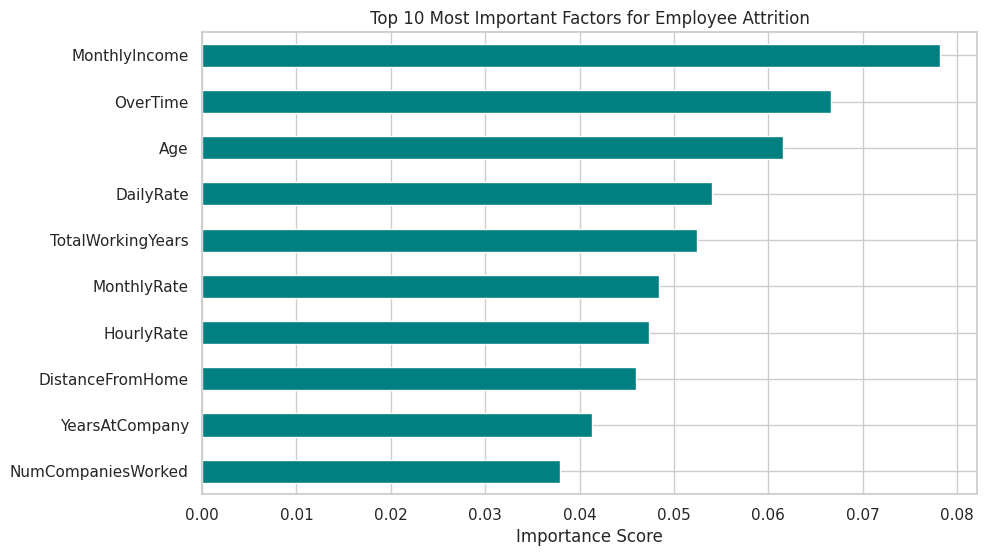

In [22]:
# Get feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Show top 10 most important features
print("Top 10 Factors affecting Attrition:")
print(feature_importance.head(10))

# Plot top 10
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Factors for Employee Attrition')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

### Final Business Recommendations

1. **Reduce OverTime** – Employees working overtime have significantly higher attrition. Review workload.
2. **Focus on Sales & Lab Technicians** – These roles have higher exit rates. Improve career growth and support.
3. **Support Younger Employees** – Younger staff leave more. Introduce mentorship and clear career paths.
4. **Improve Compensation for Low Income Groups** – Lower monthly income is linked to higher attrition.
5. **Increase Job Satisfaction** – Conduct regular surveys and act on feedback, especially for low satisfaction scores.
6. **Early Intervention** – Employees with fewer years at the company are at higher risk. Strengthen onboarding and engagement in first 2 years.